# Multi-seed evaluation of the LSTM forecaster

`Eco-Cruise_Control_for_EVs.ipynb` trains one LSTM (seed 42). Training is deterministic for a seed, but different seeds
(different synthetic data and initial weights) give noticeably different forecasters, so this notebook repeats the LSTM
part with five seeds: data generation, training, the forecasts on the EPA cycles, and every simulation that uses them
(PID + LSTM feedforward, and the MPC + LSTM energy-weight sweep).

The other forecasts (persistence, constant acceleration, oracle) and controllers do not depend on the seed; their results
are read from the CSVs the main notebook writes, so **run the main notebook first**. Runtime: about 40 minutes on a
laptop CPU.

In [1]:
import os, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import nbformat

# Replay the main notebook's definition cells (simulator, forecasts, LSTM, controllers) so both notebooks share one
# implementation.
MAIN = "Eco-Cruise_Control_for_EVs.ipynb"
defs = [c.source for c in nbformat.read(MAIN, as_version=4).cells
        if c.cell_type == "code" and c.source.startswith("# ── Definitions:")]
assert len(defs) == 6, f"expected 6 definition cells in {MAIN}, found {len(defs)}"
for s in defs:
    exec(s, globals())

SEEDS = [42, 1, 2, 3, 4]                          # 42 is the main notebook's seed
WEIGHTS = [0.0, 0.001, 0.003, 0.01]               # MPC energy weights, as in the main notebook
CYCLE_FILES = {"UDDS (city)": "uddscol.txt", "HWFET (highway)": "hwycol.txt", "US06 (aggressive)": "us06col.txt"}
cycles = {name: load_cycle(os.path.join("data", "drive_cycles", f)) for name, f in CYCLE_FILES.items()}

for f in ["results/controller_results.csv", "results/mpc_tradeoff.csv"]:
    assert os.path.exists(f), f"{f} missing: run Eco-Cruise_Control_for_EVs.ipynb first"
base = pd.read_csv("results/controller_results.csv")
sweep_ref = pd.read_csv("results/mpc_tradeoff.csv")

## 1. Train one LSTM per seed and forecast the EPA cycles

In [2]:
rmse = lambda a, b: float(np.sqrt(np.mean((a - b) ** 2)))
lstm_fc, fc_rows = {}, []
for seed in SEEDS:
    t0 = time.time()
    _, data = make_dataset(seed)
    model, hist = train_forecaster(data, seed)
    X_va, Y_va = data["val"]
    row = {"seed": seed, "epochs": len(hist["loss"]), "synthetic val": rmse(lstm_forecast(model, X_va), Y_va)}
    for name, ref in cycles.items():
        lstm_fc[(seed, name)] = lstm_forecast(model, history_windows(ref, SEQ))
        row[name] = rmse(lstm_fc[(seed, name)], forecast_oracle(ref))
    fc_rows.append(row)
    print(f"seed {seed:>2}: {row['epochs']} epochs, {time.time() - t0:.0f} s | " +
          " | ".join(f"{n.split()[0]} {row[n]:.3f}" for n in cycles))

fc = pd.DataFrame(fc_rows).set_index("seed")
ref_rows = {"persistence": {}, "const. accel": {}}
for name, ref in cycles.items():
    truth = forecast_oracle(ref)
    ref_rows["persistence"][name] = rmse(forecast_persistence(ref), truth)
    ref_rows["const. accel"][name] = rmse(forecast_const_accel(ref), truth)
summary = pd.DataFrame({"LSTM mean": fc[list(cycles)].mean(), "LSTM sd": fc[list(cycles)].std(),
                        "LSTM best seed": fc[list(cycles)].min(), "LSTM worst seed": fc[list(cycles)].max(),
                        "persistence": pd.Series(ref_rows["persistence"]),
                        "const. accel": pd.Series(ref_rows["const. accel"])})
display(summary.round(3))
print("2 s forecast RMSE (m/s) on the EPA cycles.")

seed 42: 16 epochs, 273 s | UDDS 0.261 | HWFET 0.125 | US06 0.520


seed  1: 32 epochs, 523 s | UDDS 0.314 | HWFET 0.156 | US06 0.599


seed  2: 22 epochs, 361 s | UDDS 0.294 | HWFET 0.164 | US06 0.521


seed  3: 9 epochs, 151 s | UDDS 0.382 | HWFET 0.240 | US06 0.573


seed  4: 10 epochs, 168 s | UDDS 0.346 | HWFET 0.202 | US06 0.544


,LSTM mean,LSTM sd,LSTM best seed,LSTM worst seed,persistence,const. accel
UDDS (city),0.320,0.046,0.261,0.382,0.729,0.292
HWFET (highway),0.177,0.045,0.125,0.240,0.352,0.133
US06 (aggressive),0.551,0.034,0.520,0.599,1.133,0.582


2 s forecast RMSE (m/s) on the EPA cycles.


## 2. Simulations with each seed's forecasts

In [3]:
tasks, keys = [], []
for seed in SEEDS:
    for name, ref in cycles.items():
        tasks.append((("pid", {"kff": 400}), ref, lstm_fc[(seed, name)])); keys.append((seed, name, "PID + LSTM", None))
        for w in WEIGHTS:
            tasks.append((("mpc", {"w_energy": w}), ref, lstm_fc[(seed, name)])); keys.append((seed, name, "MPC + LSTM", w))
t0 = time.time()
out = run_parallel(tasks)
print(f"{len(tasks)} simulations in {time.time() - t0:.0f} s")
sims = pd.DataFrame([{"seed": s, "cycle": c, "controller": l, "w_energy": w, **m}
                     for (s, c, l, w), (_, m) in zip(keys, out)])
sims.to_csv("results/multi_seed_simulations.csv", index=False)

75 simulations in 514 s


## 3. Energy at the PID's tracking error

As in the main notebook: each MPC + LSTM sweep interpolated to the plain PID's tracking error on the same cycle. The
oracle, constant-acceleration and persistence values come from the main notebook (they do not depend on the seed).

In [4]:
rows = []
for name in cycles:
    pid = base[(base.cycle == name) & (base.controller == "PID")].iloc[0]
    saving = lambda e: 100 * (pid["Wh/km"] - e) / pid["Wh/km"]
    for seed in SEEDS:
        s = sims[(sims.seed == seed) & (sims.cycle == name) & (sims.controller == "MPC + LSTM")]
        mpc_default = s[s.w_energy == 0.001].iloc[0]
        pidl = sims[(sims.seed == seed) & (sims.cycle == name) & (sims.controller == "PID + LSTM")].iloc[0]
        rows.append({"cycle": name, "seed": seed,
                     "MPC + LSTM saving at PID tracking (%)": saving(energy_at_tracking(s.to_dict("records"), pid["RMSE (m/s)"])),
                     "MPC + LSTM jerk (m/s³)": mpc_default["RMS jerk (m/s³)"],
                     "PID + LSTM energy vs PID (%)": saving(pidl["Wh/km"]),
                     "PID + LSTM RMSE (m/s)": pidl["RMSE (m/s)"]})
per_seed = pd.DataFrame(rows)
per_seed.to_csv("results/multi_seed_lstm.csv", index=False)

refs = {}
for name in cycles:
    pid = base[(base.cycle == name) & (base.controller == "PID")].iloc[0]
    for fc_name in ["const. accel", "oracle"]:
        e = energy_at_tracking(sweep_ref[(sweep_ref.cycle == name) & (sweep_ref.forecast == fc_name)].to_dict("records"),
                                   pid["RMSE (m/s)"])
        refs[(name, fc_name)] = 100 * (pid["Wh/km"] - e) / pid["Wh/km"]
    refs[(name, "oracle jerk")] = base[(base.cycle == name) & (base.controller == "MPC + oracle")]["RMS jerk (m/s³)"].iloc[0]
    refs[(name, "PID RMSE")] = pid["RMSE (m/s)"]

table = per_seed.groupby("cycle", sort=False).agg(["mean", "std"]).drop(columns="seed")
table.columns = [f"{a} {b}" for a, b in table.columns]
table["MPC + const. accel saving (%)"] = [refs[(n, "const. accel")] for n in table.index]
table["MPC + oracle saving (%)"] = [refs[(n, "oracle")] for n in table.index]
table["MPC + oracle jerk (m/s³)"] = [refs[(n, "oracle jerk")] for n in table.index]
table["PID RMSE (m/s)"] = [refs[(n, "PID RMSE")] for n in table.index]
display(table.T.round(2))

cycle,UDDS (city),HWFET (highway),US06 (aggressive)
MPC + LSTM saving at PID tracking (%) mean,1.04,0.02,-0.92
MPC + LSTM saving at PID tracking (%) std,0.78,0.55,1.73
MPC + LSTM jerk (m/s³) mean,2.26,1.17,3.83
MPC + LSTM jerk (m/s³) std,0.76,0.53,1.27
PID + LSTM energy vs PID (%) mean,-0.03,-0.03,-0.40
PID + LSTM energy vs PID (%) std,0.03,0.02,0.11
PID + LSTM RMSE (m/s) mean,0.20,0.08,0.29
PID + LSTM RMSE (m/s) std,0.01,0.00,0.01
MPC + const. accel saving (%),0.61,0.29,-0.28
MPC + oracle saving (%),2.63,0.73,4.33


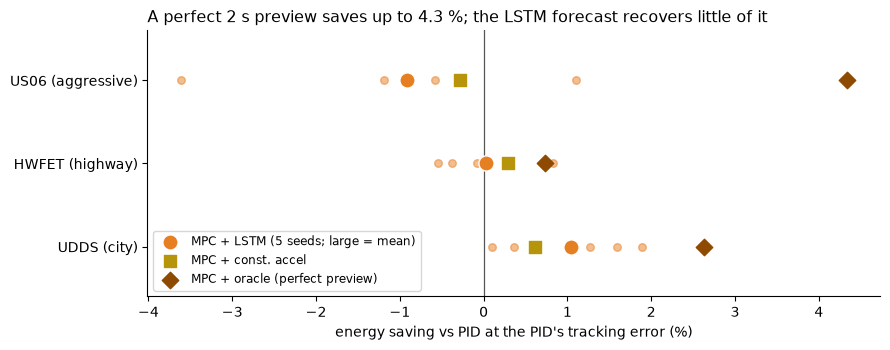

In [5]:
fig, ax = plt.subplots(figsize=(9, 3.6))
names = list(cycles)
for yi, name in enumerate(names):
    vals = per_seed[per_seed.cycle == name]["MPC + LSTM saving at PID tracking (%)"].values
    ax.scatter(vals, np.full(len(vals), yi), s=30, color="#e67e22", alpha=0.5, zorder=2)
    ax.scatter(vals.mean(), yi, s=120, color="#e67e22", edgecolor="white", zorder=3,
               label="MPC + LSTM (5 seeds; large = mean)" if yi == 0 else None)
    ax.scatter(refs[(name, "const. accel")], yi, marker="s", s=70, color="#b7950b", zorder=3,
               label="MPC + const. accel" if yi == 0 else None)
    ax.scatter(refs[(name, "oracle")], yi, marker="D", s=70, color="#8e4a00", zorder=3,
               label="MPC + oracle (perfect preview)" if yi == 0 else None)
ax.axvline(0, color="#555555", lw=0.9)
ax.set_yticks(range(len(names)), names)
ax.set_ylim(-0.6, len(names) - 0.4)
ax.set_xlabel("energy saving vs PID at the PID's tracking error (%)")
ax.set_title("A perfect 2 s preview saves up to 4.3 %; the LSTM forecast recovers little of it", loc="left", fontsize=11.5)
ax.legend(fontsize=8.5, loc="lower left")
for side in ("top", "right"):
    ax.spines[side].set_visible(False)
plt.tight_layout()
plt.savefig("results/fig_multi_seed.png", dpi=170, bbox_inches="tight")
plt.show()

## 4. Summary

In [6]:
for name in cycles:
    s = per_seed[per_seed.cycle == name]
    v = s["MPC + LSTM saving at PID tracking (%)"]
    print(f"{name}: forecast RMSE LSTM {fc[name].mean():.3f} ± {fc[name].std():.3f} vs const. accel "
          f"{ref_rows['const. accel'][name]:.3f} | MPC saving at PID tracking: LSTM {v.mean():+.1f}% ± {v.std():.1f} "
          f"(seeds {v.min():+.1f} to {v.max():+.1f}), const. accel {refs[(name, 'const. accel')]:+.1f}%, "
          f"oracle {refs[(name, 'oracle')]:+.1f}%")

UDDS (city): forecast RMSE LSTM 0.320 ± 0.046 vs const. accel 0.292 | MPC saving at PID tracking: LSTM +1.0% ± 0.8 (seeds +0.1 to +1.9), const. accel +0.6%, oracle +2.6%
HWFET (highway): forecast RMSE LSTM 0.177 ± 0.045 vs const. accel 0.133 | MPC saving at PID tracking: LSTM +0.0% ± 0.6 (seeds -0.5 to +0.8), const. accel +0.3%, oracle +0.7%
US06 (aggressive): forecast RMSE LSTM 0.551 ± 0.034 vs const. accel 0.582 | MPC saving at PID tracking: LSTM -0.9% ± 1.7 (seeds -3.6 to +1.1), const. accel -0.3%, oracle +4.3%
